In [1]:
import cv2
import torch
from moge.model.v1 import MoGeModel

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import zarr
from diffusion_policy.common.replay_buffer import ReplayBuffer
from omegaconf import OmegaConf
from diffusion_policy.codecs.imagecodecs_numcodecs import register_codecs
from umi.common.pose_util import (
    pose_to_mat, mat_to_pose, 
    mat_to_pose10d, pose10d_to_mat)
from diffusion_policy.common.pose_repr_util import convert_pose_mat_rep

In [3]:
from PIL import Image
import plotly.express as px
import pandas as pd     

In [4]:
OmegaConf.register_new_resolver("eval", eval, replace=True)
register_codecs()

In [5]:
zarr_path = '/home/soochul/GoPro_20250519/dataset.zarr.zip'
zip_store = zarr.ZipStore(zarr_path, mode='a')
root = zarr.group(zip_store)
replay_buffer = ReplayBuffer.create_from_group(root)
num_episodes = len(replay_buffer.episode_ends)
episode_idx = np.random.choice(num_episodes)
ep = replay_buffer.get_episode(episode_idx)
print(ep.keys()) 
# dict_keys(['camera0_rgb', 'robot0_demo_end_pose', 'robot0_demo_start_pose', 
# 'robot0_eef_pos', 'robot0_eef_rot_axis_angle', 
# 'robot0_force', 'robot0_gripper_width', 'robot0_torque'])

dict_keys(['camera0_rgb', 'robot0_demo_end_pose', 'robot0_demo_start_pose', 'robot0_eef_pos', 'robot0_eef_rot_axis_angle', 'robot0_force', 'robot0_gripper_width', 'robot0_torque'])


In [6]:
device = torch.device("cuda")

# model = MoGeModel.from_pretrained("Ruicheng/moge-vitl").to(device)
model = MoGeModel.from_pretrained("Ruicheng/moge-vitl").half().to(device)  

/home/soochul/miniforge3/envs/umi/lib/python3.9/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/soochul/miniforge3/envs/umi/lib/python3.9/site-packages/moge/model/v1.py:171: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")


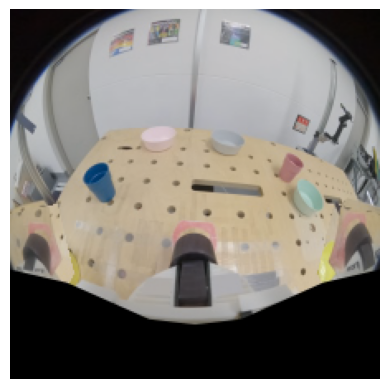

In [7]:
image_replay = ep['camera0_rgb'][:]
num_images = len(image_replay) # 552
img_arr = image_replay[180]
# print(type(img_arr))
img = Image.fromarray(img_arr, 'RGB')
# print(img.size)
plt.imshow(img_arr)
plt.axis('off')
plt.show()

In [8]:
def crop_inside_circle(img: np.ndarray,
                       out_size: tuple[int, int] = (224, 224)) -> np.ndarray:
    h, w = img.shape[:2]
    side = int(min(h, w) / np.sqrt(2))        # largest inscribed square
    y0   = (h - side) // 2                    # top-left corner
    x0   = (w - side) // 2
    masked_side = int(side * 0.9)
    # patch = img[y0:y0 + side, x0:x0 + side]   # crop
    patch = img[y0:y0 + masked_side, x0:x0 + side]   # crop
    if out_size is not None and (side, side) != out_size:
        patch = cv2.resize(patch, out_size, interpolation=cv2.INTER_AREA)
    return patch

In [9]:
def crop_area(img: np.ndarray,
                       out_size: tuple[int, int] = (224, 224)) -> np.ndarray:
    h, w = img.shape[:2]
    side = int(min(h, w) / np.sqrt(2))        
    y0   = (h - side) // 2                    
    x0   = (w - side) // 2

    masked_side = int(side * 0.9)

    cropped = img.copy()

    # img[y0:y0 + side, x0:x0 + side] = 255
    # img[y0, x0] = 255
    cropped[y0:y0 + masked_side, x0:x0+side] = 255
    # img[y0 + side, x0] = 255
    # img[y0, x0 + side] = 255
    # img[y0 + masked_side, x0 + side] = 255
    # img[y0 + side, x0 + side] = 255
    return cropped

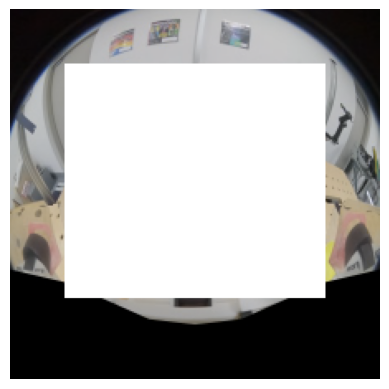

In [10]:
masked_img = crop_area(img_arr)
plt.imshow(masked_img); plt.axis('off'); plt.show()

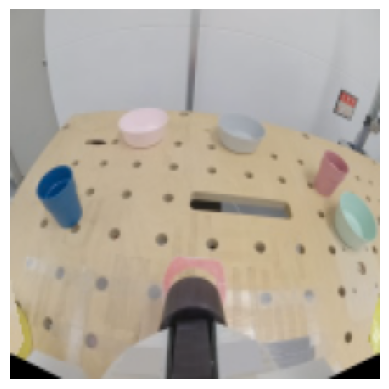

In [11]:
clean_img = crop_inside_circle(img_arr)
plt.imshow(clean_img); plt.axis('off'); plt.show()

In [ ]:
# input_image = cv2.cvtColor(cv2.imread(img), cv2.COLOR_BGR2RGB)                       
# input_image = torch.tensor(input_image / 255, dtype=torch.float32, device=device).permute(2, 0, 1) 
# output = model.infer(input_image)   

In [12]:
img_arr = clean_img

In [13]:
input_tensor = (torch.tensor(img_arr, dtype=torch.float32)
                      .permute(2, 0, 1)       # (3, H, W)
                      / 255.0)                # scale

input_tensor = input_tensor.to(device)
output = model.infer(input_tensor) 

In [14]:
from mpl_toolkits.mplot3d import Axes3D

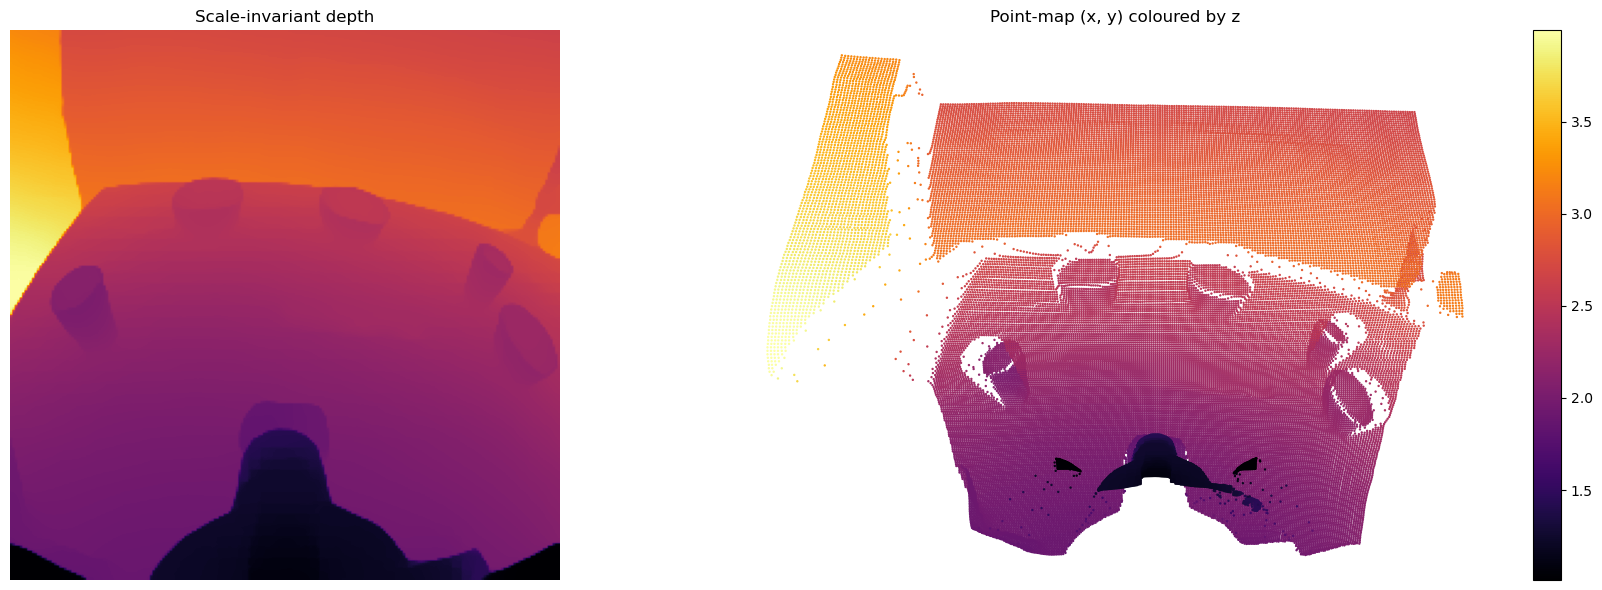

In [15]:
depth   = output["depth"     ].detach().cpu().numpy()    # (H, W)
mask    = output["mask"      ].detach().cpu().numpy()    # (H, W)   0/1
points  = output["points"    ].detach().cpu().numpy()    # (H, W, 3)
K       = output["intrinsics"].detach().cpu().numpy()    # (3, 3)   (optional)

valid   = mask.astype(bool)                             # Boolean mask
xyz     = points[valid]                                 # (N, 3) only valid pts


fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# depth
d_norm = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)  # 0-1
ax[0].imshow(d_norm, cmap="inferno")
ax[0].set_title("Scale-invariant depth")
ax[0].axis("off")

# projected point-map (x-y -> colour by z)
scatter = ax[1].scatter(xyz[:, 0], xyz[:, 1],
                        c=xyz[:, 2], s=0.5, cmap="inferno")
ax[1].invert_yaxis()         # y-down to match image coordinates
ax[1].set_aspect("equal")
ax[1].set_title("Point-map (x, y) coloured by z")
ax[1].axis("off")
plt.colorbar(scatter, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [16]:
# xyz is (N, 3) NumPy array from MoGe output
cloud = pd.DataFrame(xyz, columns=["x", "y", "z"])

fig = px.scatter_3d(
    cloud, x="x", y="y", z="z",
    color="z",                 # colour code by depth
    size_max=0.1,                # tiny dots (px)
    opacity=0.6,
)

fig.update_layout(
    scene_aspectmode="data",   # keep real aspect ratio
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [53]:
zarr_path = '/home/soochul/GoPro_20250523/dataset.zarr.zip'
zip_store = zarr.ZipStore(zarr_path, mode='a')
root = zarr.group(zip_store)
replay_buffer = ReplayBuffer.create_from_group(root)
num_episodes = len(replay_buffer.episode_ends)
episode_idx = np.random.choice(num_episodes)
ep = replay_buffer.get_episode(episode_idx)

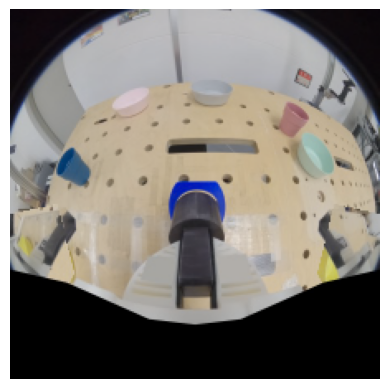

In [54]:
image_replay = ep['camera0_rgb'][:]
num_images = len(image_replay) # 552
img_arr = image_replay[420]
# print(type(img_arr))
img = Image.fromarray(img_arr, 'RGB')
# print(img.size)
plt.imshow(img_arr)
plt.axis('off')
plt.show()

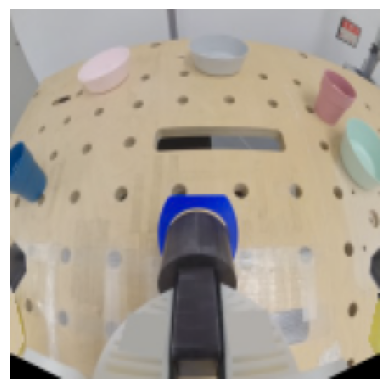

In [55]:
clean_img = crop_inside_circle(img_arr)
plt.imshow(clean_img); plt.axis('off'); plt.show()

In [56]:
img_arr = clean_img

input_tensor = (torch.tensor(img_arr, dtype=torch.float32)
                      .permute(2, 0, 1)       # (3, H, W)
                      / 255.0)                # scale

input_tensor = input_tensor.to(device)
output = model.infer(input_tensor) 

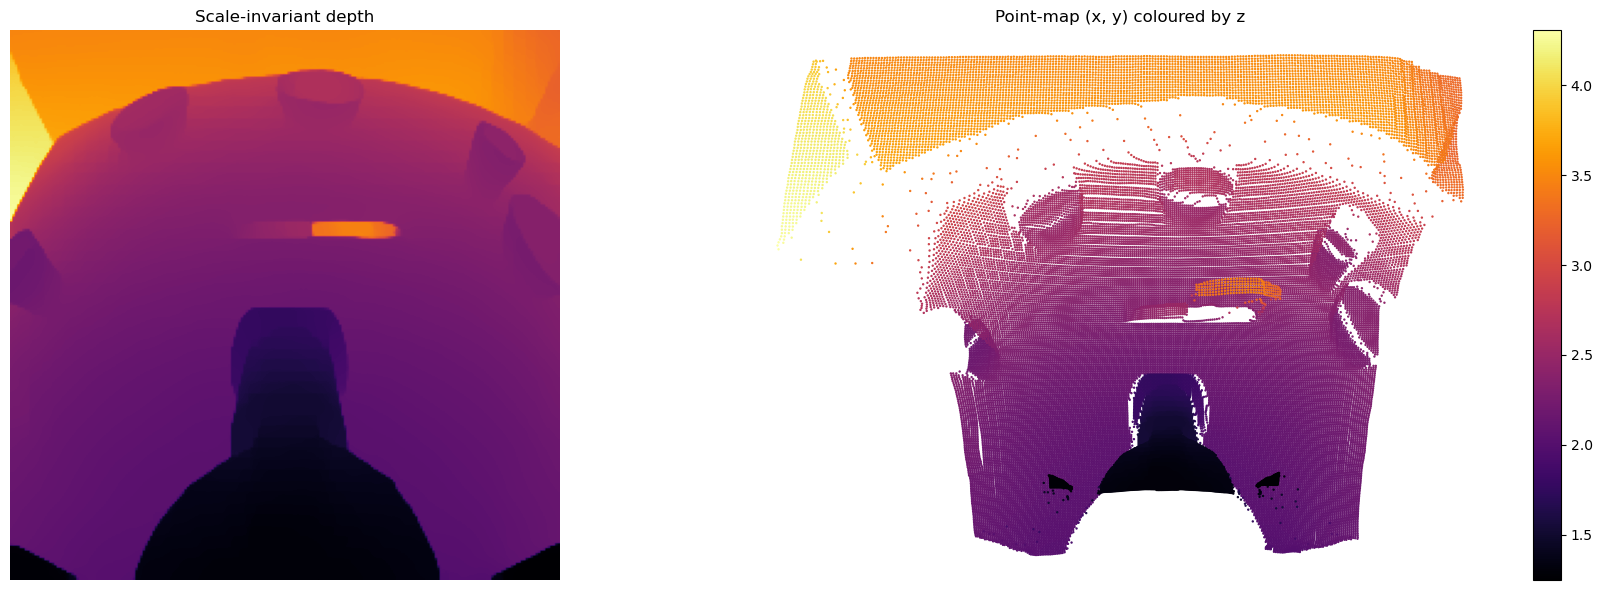

In [57]:
depth   = output["depth"     ].detach().cpu().numpy()    # (H, W)
mask    = output["mask"      ].detach().cpu().numpy()    # (H, W)   0/1
points  = output["points"    ].detach().cpu().numpy()    # (H, W, 3)
K       = output["intrinsics"].detach().cpu().numpy()    # (3, 3)   (optional)

valid   = mask.astype(bool)                             # Boolean mask
xyz     = points[valid]                                 # (N, 3) only valid pts


fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# depth
d_norm = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)  # 0-1
ax[0].imshow(d_norm, cmap="inferno")
ax[0].set_title("Scale-invariant depth")
ax[0].axis("off")

# projected point-map (x-y -> colour by z)
scatter = ax[1].scatter(xyz[:, 0], xyz[:, 1],
                        c=xyz[:, 2], s=0.5, cmap="inferno")
ax[1].invert_yaxis()         # y-down to match image coordinates
ax[1].set_aspect("equal")
ax[1].set_title("Point-map (x, y) coloured by z")
ax[1].axis("off")
plt.colorbar(scatter, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [58]:
cloud = pd.DataFrame(xyz, columns=["x", "y", "z"])

fig = px.scatter_3d(
    cloud, x="x", y="y", z="z",
    color="z",                 # colour code by depth
    size_max=0.1,                # tiny dots (px)
    opacity=0.6,
)

fig.update_layout(
    scene_aspectmode="data",   # keep real aspect ratio
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [59]:
def depth_to_rgb(depth: np.ndarray,
                 mask:  np.ndarray,
                 cmap:  str = "inferno",
                 use_cv2: bool = True) -> np.ndarray:
    # ---------------- 1) pick only valid pixels & normalise --------------
    if mask is not None:
        depth = np.where(mask.astype(bool), depth, np.nan)

    # ignore NaNs when computing min/max
    d_min = np.nanmin(depth)
    d_max = np.nanmax(depth)
    d_norm = (depth - d_min) / (d_max - d_min + 1e-8)       # 0-1
    d_uint8 = np.nan_to_num(d_norm * 255).astype(np.uint8)   # 0-255

    # ---------------- 2) map to colour -----------------------------------
    if use_cv2:
        # OpenCV expects BGR; we'll convert to RGB afterwards.
        cv2_cmap = getattr(cv2, f"COLORMAP_{cmap.upper()}", cv2.COLORMAP_INFERNO)
        bgr = cv2.applyColorMap(d_uint8, cv2_cmap)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    else:
        mpl_cmap = plt.get_cmap(cmap)
        rgb = (mpl_cmap(d_norm)[:, :, :3] * 255).astype(np.uint8)  # drop alpha

    # ---------------- 3) zero-out invalid pixels -------------------------
    if mask is not None:
        rgb[~mask.astype(bool)] = 0

    return rgb

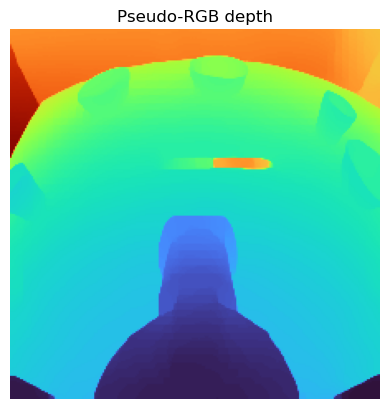

In [60]:
depth   = output["depth"     ].detach().cpu().numpy()
mask    = output["mask"      ].detach().cpu().numpy()

# depth_rgb = depth_to_rgb(depth, mask=mask, cmap="rainbow", use_cv2=True)
depth_rgb = depth_to_rgb(depth, mask=mask, cmap="turbo", use_cv2=True)

plt.imshow(depth_rgb); plt.axis('off'); plt.title("Pseudo-RGB depth"); plt.show()

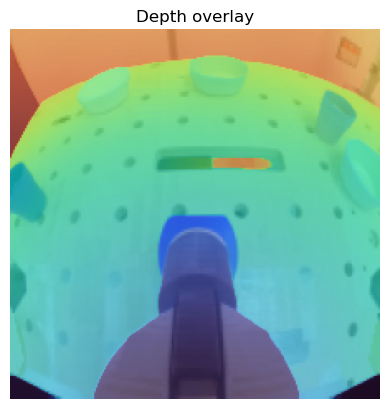

In [61]:
alpha = 0.6
overlay = cv2.addWeighted(clean_img, 1 - alpha, depth_rgb, alpha, 0)
plt.imshow(overlay); plt.axis('off'); plt.title("Depth overlay"); plt.show()

In [62]:
img = Image.fromarray(img_arr, 'RGB')
img_arr = image_replay[420]


points  = output["points"    ].detach().cpu().numpy()
xyz     = points[valid]  
rgb  = (img_arr / 255.0)[mask]  

In [51]:
import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [64]:
pc = o3d.geometry.PointCloud()
pc.points = o3d.utility.Vector3dVector(xyz)
pc.colors = o3d.utility.Vector3dVector(rgb)
o3d.visualization.draw_geometries([pc])

In [65]:
zarr_path = '/home/soochul/GoPro_20250519/dataset.zarr.zip'
zip_store = zarr.ZipStore(zarr_path, mode='a')
root = zarr.group(zip_store)
replay_buffer = ReplayBuffer.create_from_group(root)
num_episodes = len(replay_buffer.episode_ends)
episode_idx = np.random.choice(num_episodes)
ep = replay_buffer.get_episode(episode_idx)
print(ep.keys()) 

dict_keys(['camera0_depth', 'camera0_rgb', 'robot0_demo_end_pose', 'robot0_demo_start_pose', 'robot0_eef_pos', 'robot0_eef_rot_axis_angle', 'robot0_force', 'robot0_gripper_width', 'robot0_torque'])


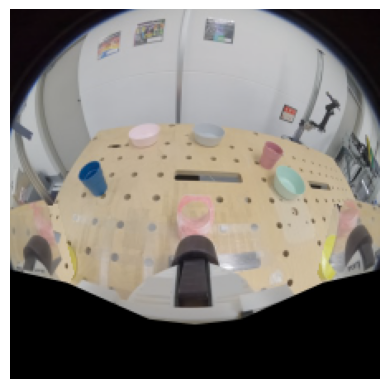

In [66]:
image_replay = ep['camera0_rgb'][:]
depth_replay = ep['camera0_depth'][:]
num_images = len(image_replay) # 552
img_arr = image_replay[180]
depth_arr = depth_replay[180]
# print(type(img_arr))
img = Image.fromarray(img_arr, 'RGB')
depth_img = Image.fromarray(depth_arr, 'RGB')
# print(img.size)
plt.imshow(img_arr)
plt.axis('off')
plt.show()

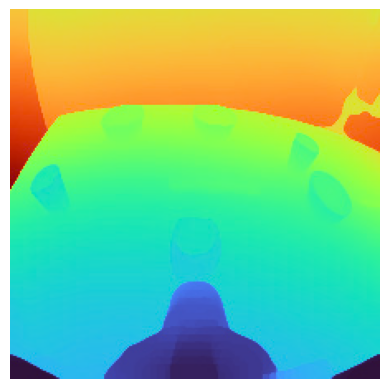

In [67]:
plt.imshow(depth_arr)
plt.axis('off')
plt.show()